# QuantFundAgent — End-to-End Showcase

A LangGraph **multi-agent quant fund** that researches factors, builds ML
strategies, validates them statistically, and allocates capital — mirroring a
systematic trading desk:

**Factor Researcher → Selector → Architect (ML) → Statistician → Portfolio Manager**

This notebook walks the full workflow on 10-second intraday US-equity data with
KPIs, figures and architecture diagrams.  It runs in **cached mode** by default
(loads the artifacts from a `run_fund.py` run); set `RUN_LIVE = True` in the next
cell to drive the agents live.

In [1]:
from __future__ import annotations
import os, json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display
warnings.filterwarnings("ignore")

from dotenv import load_dotenv; load_dotenv()
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3})

# Cached by default.  True -> re-run the agent pipeline live (needs OPENAI_API_KEY).
RUN_LIVE = False

DATA = Path("data")
from quant_fund_agent.factors import discover_factors
discover_factors()

show = json.load(open(DATA / "strategies" / "showcase.json"))
HORIZON = show["target_horizon"]
print(f"RUN_LIVE={RUN_LIVE} | forecast horizon={HORIZON} bars "
      f"({HORIZON*10}s) | universe={show['n_tickers']} tickers")

def _showcase_text(val) -> str:
    """Hypothesis / rationale from showcase.json may be str or a factor→reason dict."""
    if not val:
        return "(n/a)"
    if isinstance(val, str):
        return val
    if isinstance(val, dict):
        return "\n".join(f"  • {k}: {v}" for k, v in val.items())
    return str(val)

RUN_LIVE=False | forecast horizon=6 bars (60s) | universe=10 tickers


## Factor universe & multi-horizon IC (analyst view)

The alpha factors' predictive power (rank-IC) **peaks at the 10-second horizon** and decays as the horizon lengthens.  Note: the Selector is **deliberately blind** to these IC numbers — it chooses factors on economic role and diversity so the ML model can exploit interactions (a weak-IC volatility factor can be valuable *combined* with momentum). This table is for us, the analysts.

89 factors across 5 categories


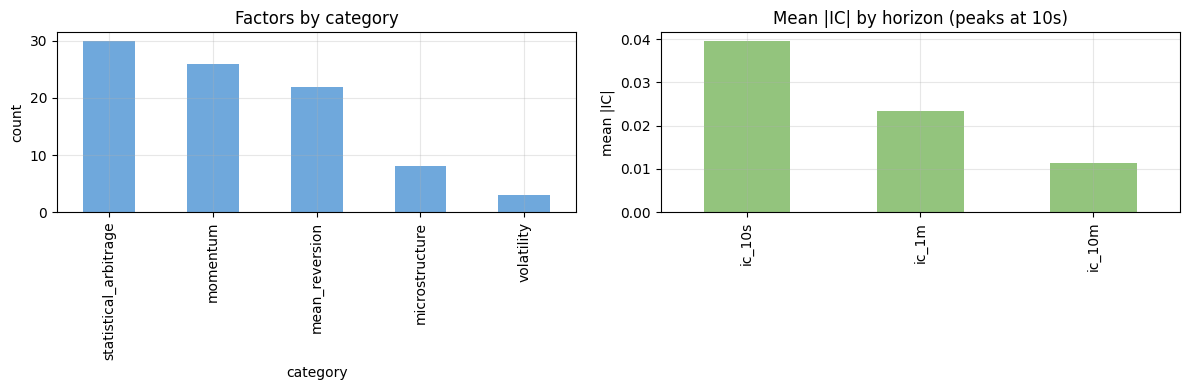

,id,name,category,ic_10s,ic_1m,ic_10m
0,alpha_033,Alpha#33,mean_reversion,0.234896,0.115748,0.039401
1,alpha_101,Alpha#101,microstructure,-0.229775,-0.112445,-0.038213
2,alpha_041,Alpha#41,mean_reversion,0.225451,0.110220,0.037886
3,alpha_054,Alpha#54,mean_reversion,0.212935,0.102810,0.035021
4,alpha_083,Alpha#83,microstructure,0.195339,0.098798,0.032451
5,alpha_057,Alpha#57,mean_reversion,0.181591,0.087173,0.027466
6,alpha_038,Alpha#38,momentum,0.174648,0.096142,0.039188
7,alpha_060,Alpha#60,microstructure,0.153396,0.079662,0.020360
8,alpha_042,Alpha#42,mean_reversion,0.134394,0.066709,0.029170
9,alpha_005,Alpha#5,mean_reversion,0.133388,0.077264,0.033424


In [4]:
fdb = json.load(open(DATA / "factors" / "factor_db.json"))
rows = []
for f in fdb["factors"]:
    by = (f.get("backtest_metrics") or {}).get("ic_by_horizon", {})
    rows.append({"id": f["id"], "name": f["name"], "category": f.get("category", ""),
                 "ic_10s": (by.get("1") or {}).get("ic"),
                 "ic_1m": (by.get("6") or {}).get("ic"),
                 "ic_10m": (by.get("60") or {}).get("ic")})
fac = pd.DataFrame(rows)
print(f"{len(fac)} factors across {fac.category.nunique()} categories")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
fac.category.value_counts().plot(kind="bar", ax=ax[0], title="Factors by category", color="#6fa8dc")
ax[0].set_ylabel("count")
fac[["ic_10s", "ic_1m", "ic_10m"]].abs().mean().plot(
    kind="bar", ax=ax[1], title="Mean |IC| by horizon (peaks at 10s)", color="#93c47d")
ax[1].set_ylabel("mean |IC|")
plt.tight_layout(); plt.show()

display(fac.reindex(fac.ic_10s.abs().sort_values(ascending=False).index)
        .head(10).reset_index(drop=True))

## 4. Selector — IC-blind hypothesis & factor choice

The Selector forms a trading hypothesis and picks a *diversified, complementary* set of factors without seeing any IC scores.

In [6]:
entries = show["entries"]
accepted = [e for e in entries if e.get("approved")]
focus = (accepted[0] if accepted else (entries[0] if entries else None))
assert focus is not None, "No strategy attempts found in showcase.json"
print("Focus strategy is", "ACCEPTED" if focus.get("approved") else f"REJECTED ({focus.get('reject_stage')})")

print("\nHYPOTHESIS\n" + "-"*60 + "\n" + _showcase_text(focus.get("hypothesis")))
print("\nSELECTION RATIONALE\n" + "-"*60 + "\n" + _showcase_text(focus.get("selection_rationale")))
chosen = fac[fac.id.isin(focus["factor_ids"])][["id", "name", "category"]].reset_index(drop=True)
print(f"\nChosen factors ({len(chosen)}) — spanning {chosen.category.nunique()} categories:")
display(chosen)

Focus strategy is ACCEPTED


NameError: name '_showcase_text' is not defined

## 5. Architect — model selection across trials

Each trial fits a model from the toolbox (regression / random forest / gradient boosting / XGBoost / LightGBM) and is scored by **held-out validation rank-IC**; the `train_r2` vs `valid_r2` gap flags overfitting.

In [ ]:
trials = pd.DataFrame(focus["trials"])
if not trials.empty:
    cols = [c for c in ["iteration","model_type","n_features","valid_ic","train_r2","valid_r2","is_sharpe"] if c in trials]
    display(trials[cols].round(5))
    fig, ax = plt.subplots(figsize=(8, 3.2))
    ax.bar(trials["iteration"].astype(str) + " · " + trials["model_type"], trials["valid_ic"], color="#6fa8dc")
    ax.set_title("Validation rank-IC by trial (selection criterion)"); ax.set_ylabel("valid IC"); plt.xticks(rotation=20)
    plt.tight_layout(); plt.show()
print("Chosen model:", focus["model_type"], "| params:", focus["model_params"])

## 6. Performance — in-sample vs out-of-sample

The persisted model is reloaded (never refit) and back-tested on both the in-sample window and the held-out OOS slice the Architect never saw.

In [ ]:
from quant_fund_agent.modeling import service
from quant_fund_agent.backtesting.data_split import split_panel, split_signals
from quant_fund_agent.backtesting.strategy_backtester import backtest_strategy
from quant_fund_agent.strategies.model_strategy import ModelStrategy
from quant_fund_agent.databases import StrategyDatabase

OOS_RATIO = 0.2
ntk = show["n_tickers"]
if isinstance(ntk, int):
    os.environ["ARCHITECT_N_TICKERS"] = str(ntk)

sdb = StrategyDatabase()
try:
    sdb.load_from_json(DATA / "strategies" / "strategy_db.json")
except Exception:
    pass
rec = next((s for s in sdb.list_strategies() if s.id == focus.get("id")), None)
p = (rec.model_params if rec else {}) or {}
artifact = p.get("model_artifact_path") or focus.get("model_artifact_path")
hp = p.get("holding_period") or focus.get("holding_period") or HORIZON
mp = p.get("max_positions") or focus.get("max_positions") or 20
mc = p.get("min_conviction") or focus.get("min_conviction") or 0.0

data_full = service._load_panel()
sig_full = {fid: service._factor_signal(fid, data_full) for fid in focus["factor_ids"]}
data_is, data_oos = split_panel(data_full, OOS_RATIO)
sig_is, sig_oos = split_signals(sig_full, OOS_RATIO)

strat = ModelStrategy.from_artifact(artifact, strategy_id="show", holding_period=hp,
                                    max_positions=mp, min_conviction=mc)
is_bt = backtest_strategy(strat, sig_is, data_is)
oos_bt = backtest_strategy(strat, sig_oos, data_oos)

fig, ax = plt.subplots(figsize=(10, 4))
isc, oosc = is_bt.cumulative_returns, oos_bt.cumulative_returns + is_bt.cumulative_returns.iloc[-1]
ax.plot(isc.index, isc.values, label="In-sample", color="tab:blue")
ax.plot(oosc.index, oosc.values, label="Out-of-sample", color="tab:orange")
ax.axvline(isc.index[-1], ls="--", color="gray")
ax.set_title(f"Cumulative return — {focus.get('name') or focus['model_type']}")
ax.set_ylabel("cumulative return"); ax.legend(); plt.show()

def kpis(m):
    return {"Sharpe": m.sharpe_ratio, "Sortino": m.sortino_ratio, "MaxDD": m.max_drawdown,
            "HitRate": m.hit_rate, "AnnReturn": m.annualised_return,
            "Turnover/day": m.avg_daily_turnover, "IC": m.ic_mean}
display(pd.DataFrame({"In-sample": kpis(is_bt.metrics), "Out-of-sample": kpis(oos_bt.metrics)}).round(4))

## 7. Statistician — acceptance gates

Every candidate must clear a **Deflated Sharpe Ratio** test (corrects for multiple testing & non-normality) and an **out-of-sample** test (positive OOS Sharpe, bounded decay vs in-sample). Thresholds are shown explicitly for transparency.

In [ ]:
print("Gates:", show.get("gates"))
print("Final decision:", focus.get("final_decision"))
st = pd.DataFrame(focus["stat_tests"])
if not st.empty:
    display(st[["test_id", "verdict", "value", "threshold", "summary"]])

overview = pd.DataFrame([{
    "approved": e.get("approved"), "reject_stage": e.get("reject_stage"),
    "model": e.get("model_type"), "is_sharpe": e.get("is_sharpe"),
    "oos_sharpe": e.get("oos_sharpe"), "deflated_sharpe": e.get("deflated_sharpe"),
} for e in entries])
print("\nAll attempts this run:")
display(overview.round(4))

## 8. Portfolio Manager — allocation & diversification

The PM (committee of risk personalities) allocates capital across the approved book and monitors cross-strategy correlation.

In [ ]:
try:
    pj = json.load(open(DATA / "portfolio" / "portfolio_db.json"))
    recs = pj.get("portfolios") or pj.get("records") or (pj if isinstance(pj, list) else [])
    if isinstance(recs, dict):
        recs = list(recs.values())
    if recs:
        last = recs[-1]
        print("PM:", last.get("pm_name"), "| method:", last.get("construction_method"))
        adf = pd.DataFrame(last.get("allocations", []))
        if not adf.empty:
            keep = [c for c in ["strategy_id", "weight", "enabled", "rationale"] if c in adf]
            display(adf[keep])
    else:
        print("No portfolio records found.")
except Exception as e:
    print("Could not render PM allocation:", e)

try:
    sdb.refresh_correlations()
    corr = sdb.correlation_matrix
    if corr is not None and len(corr) >= 1:
        fig, ax = plt.subplots(figsize=(5, 4))
        im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="coolwarm")
        ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
        ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index, fontsize=7)
        fig.colorbar(im); ax.set_title("Strategy return correlation"); plt.show()
except Exception as e:
    print("Correlation heatmap unavailable:", e)

## 9. Forecast-horizon comparison (10s · 1min · 10min)

Why trade at 1-minute when IC peaks at 10s?  A fixed model/feature set is evaluated across horizons: the **10s horizon has the highest IC but punishing turnover**, while longer horizons convert more of that signal into realised Sharpe.  (Deterministic; uses ridge.)

In [ ]:
from quant_fund_agent.modeling.service import sweep_horizons
sweep = pd.DataFrame(sweep_horizons(factor_ids=focus["factor_ids"], model_type="ridge",
                                    horizons=(1, 6, 60)))
sweep["horizon"] = sweep["target_horizon"].map({1: "10s", 6: "1min", 60: "10min"})
display(sweep[["horizon", "valid_ic", "is_ic", "oos_ic", "is_sharpe", "oos_sharpe"]].round(5))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sweep.set_index("horizon")[["valid_ic", "oos_ic"]].plot(kind="bar", ax=ax[0],
    title="IC by horizon (10s peaks)"); ax[0].set_ylabel("rank-IC")
sweep.set_index("horizon")[["is_sharpe", "oos_sharpe"]].plot(kind="bar", ax=ax[1],
    title="Sharpe by horizon"); ax[1].set_ylabel("Sharpe")
plt.tight_layout(); plt.show()

## 10. (Optional) Run the agents live

Set `RUN_LIVE = True` in the first cell to drive the real pipeline (Selector → Architect → Statistician) instead of the cached artifacts.  Requires `OPENAI_API_KEY`.

In [ ]:
if RUN_LIVE:
    from quant_fund_agent import pipeline
    res = pipeline.run_strategy_pipeline(max_iterations=2, target_horizon=HORIZON)
    print("approved:", res.approved, "| reject_stage:", res.reject_stage)
    if res.strategy_spec:
        print("model:", res.strategy_spec.model_type, "| factors:", res.strategy_spec.factor_ids)
else:
    print("RUN_LIVE is False — rendered cached results above. Set RUN_LIVE=True to re-run the agents.")